# El costo oculto del reclamo

**Decisión:** ¿Qué empresa debe entrar primero a una revisión operativa dentro de esta muestra?

Notebook ejecutado sobre la muestra versionada del repositorio.

## 1. Contrato y calidad

Se comprueba la trazabilidad de la fuente, el tamaño de la muestra y las métricas finitas.

In [1]:
from pathlib import Path
from IPython.display import Image, display
from portfolio_analytics.common import project_root, read_json
root = project_root()
project = root / 'projects/02-complaint-risk-sql'
source = read_json(project / 'data/source.json')
display({'rows': source['rows'], 'source': source['url'], 'retrieved_at': source['retrieved_at']})

{'rows': 20000,
 'source': 'https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/',
 'retrieved_at': '2026-07-30T05:01:50+00:00'}

## 2. Ejecución reproducible

La siguiente celda vuelve a correr la lógica compartida por el script y las pruebas.

In [2]:
from portfolio_analytics.complaint_sql import analyze
metrics = analyze(project / 'data/sample.csv', project / 'outputs')
display(metrics)

{'complaints': 20000,
 'companies': 479,
 'products': 11,
 'top_risk_company': 'Portfolio Recovery Associates, LLC',
 'top_risk_score': 96.12,
 'top_company_complaints': 73,
 'top_company_untimely_rate_pct': 2.74,
 'sql_window_functions': 6}

## 3. Resultado visual

La figura se genera desde los mismos datos y queda versionada para revisión rápida.

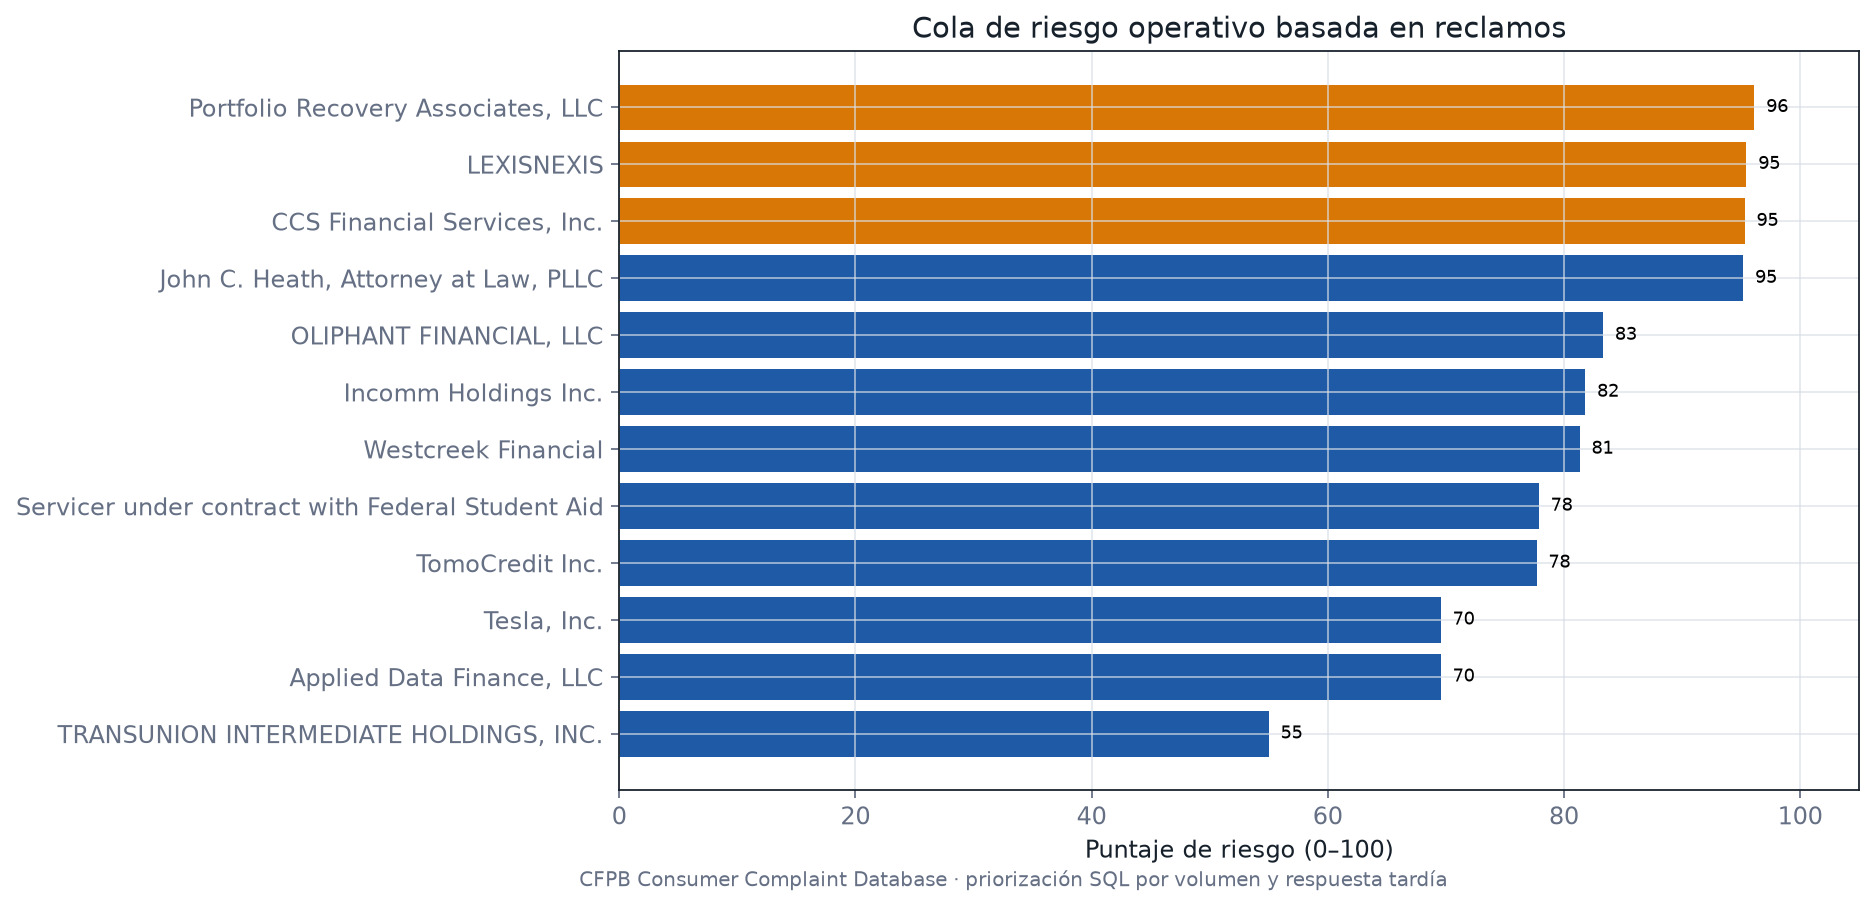

In [3]:
display(Image(filename=str(project / 'outputs/figure.png'), width=900))

## 4. Conclusión y límite

La cola combina volumen y respuesta tardía; no reemplaza un denominador de clientes.